In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Calm & consistent colors
colors = ["#6BAED6", "#FD8D3C"]

# Data Loading & Cleaning

In [ ]:
control = pd.read_csv("control_group.csv", sep=';')
test = pd.read_csv("test_group.csv", sep=';')

# Add label
control['campaign'] = 'Control'
test['campaign'] = 'Test'

# Combine
df = pd.concat([control, test], ignore_index=True)

In [ ]:
# Standardize columns
df.columns = df.columns.str.lower().str.strip()

# Remove duplicate columns (kalau ada)
df = df.loc[:, ~df.columns.duplicated()]

# Rename columns (MATCH DATASET)
df = df.rename(columns={
    'campaign name': 'campaign_name',
    'spend [usd]': 'spend',
    '# of impressions': 'impressions',
    'reach': 'reach',
    '# of website clicks': 'clicks',
    '# of searches': 'searches',
    '# of view content': 'view_content',
    '# of add to cart': 'add_to_cart',
    '# of purchase': 'purchase'
})

# Fix date (IMPORTANT)
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Handle missing
df = df.dropna()

# Final check
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59 entries, 0 to 59
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   campaign_name  59 non-null     object        
 1   date           59 non-null     datetime64[ns]
 2   spend          59 non-null     int64         
 3   impressions    59 non-null     float64       
 4   reach          59 non-null     float64       
 5   clicks         59 non-null     float64       
 6   searches       59 non-null     float64       
 7   view_content   59 non-null     float64       
 8   add_to_cart    59 non-null     float64       
 9   purchase       59 non-null     float64       
 10  campaign       59 non-null     object        
dtypes: datetime64[ns](1), float64(7), int64(1), object(2)
memory usage: 5.5+ KB


# Feature Engineering

## Funnel Metrics

In [ ]:
df['ctr'] = df['clicks'] / df['impressions']
df['view_rate'] = df['view_content'] / df['clicks']
df['cart_rate'] = df['add_to_cart'] / df['view_content']
df['purchase_rate'] = df['purchase'] / df['add_to_cart']

## Financial Metrics

In [ ]:
AOV = 50

df['revenue'] = df['purchase'] * AOV
df['profit'] = df['revenue'] - df['spend']
df['cac'] = df['spend'] / df['purchase']
df['roi'] = (df['revenue'] - df['spend']) / df['spend']

# Funnel Analysis

In [ ]:
funnel = df.groupby('campaign')[[
    'impressions',
    'clicks',
    'view_content',
    'add_to_cart',
    'purchase'
]].sum()

funnel

,impressions,clicks,view_content,add_to_cart,purchase
campaign,,,,,
Control,3177233.0,154303.0,56370.0,37700.0,15161.0
Test,2237544.0,180970.0,55740.0,26446.0,15637.0


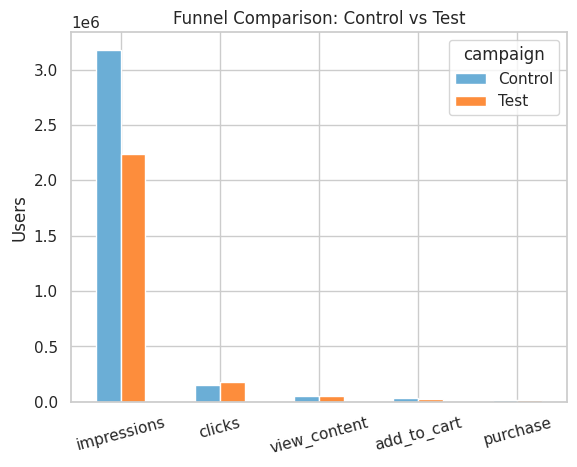

In [ ]:
funnel = df.groupby('campaign')[[
    'impressions',
    'clicks',
    'view_content',
    'add_to_cart',
    'purchase'
]].sum()

funnel.T.plot(kind='bar', color=colors)
plt.title("Funnel Comparison: Control vs Test")
plt.ylabel("Users")
plt.xticks(rotation=15)
plt.show()

# Conversion Rate Comparison

In [ ]:
conversion = df.groupby('campaign')[[
    'ctr','view_rate','cart_rate','purchase_rate'
]].mean()

conversion

,ctr,view_rate,cart_rate,purchase_rate
campaign,,,,
Control,0.050959,0.382097,0.777854,0.457179
Test,0.102423,0.327253,0.515096,0.617949


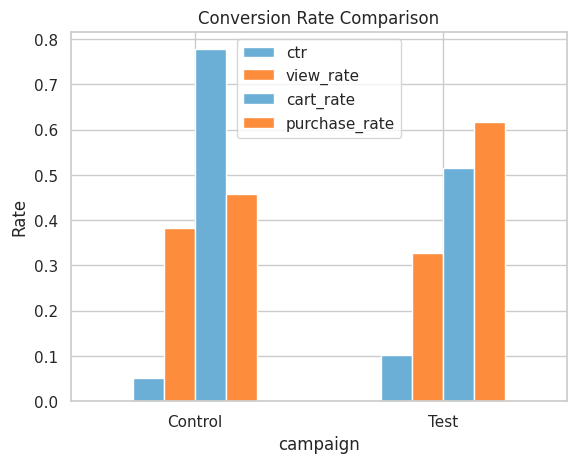

In [ ]:
conversion = df.groupby('campaign')[[
    'ctr','view_rate','cart_rate','purchase_rate'
]].mean()

conversion.plot(kind='bar', color=colors)
plt.title("Conversion Rate Comparison")
plt.ylabel("Rate")
plt.xticks(rotation=0)
plt.show()

# A/B Testing (Statistical Validation)

In [ ]:
group = df.groupby('campaign').agg({
    'purchase': 'sum',
    'clicks': 'sum'
})

success = group['purchase'].values
nobs = group['clicks'].values

from statsmodels.stats.proportion import proportions_ztest

zstat, pval = proportions_ztest(success, nobs)

print("Z-stat:", zstat)
print("P-value:", pval)

Z-stat: 11.8386745814439
P-value: 2.4631475628426749e-32


# Revenue & Profit Analysis

In [ ]:
df.groupby('campaign')[['revenue','spend','profit']].sum()

,revenue,spend,profit
campaign,,,
Control,758050.0,66818,691232.0
Test,781850.0,76892,704958.0


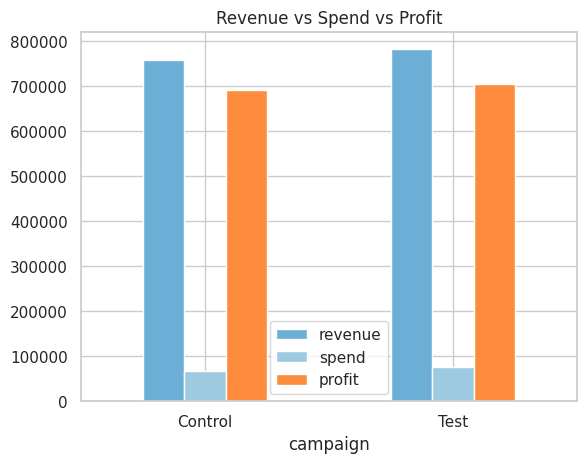

In [ ]:
df.groupby('campaign')[['revenue','spend','profit']].sum().plot(
    kind='bar',
    color=["#6BAED6", "#9ECAE1", "#FD8D3C"]
)

plt.title("Revenue vs Spend vs Profit")
plt.xticks(rotation=0)
plt.show()

# ROI Summary

In [ ]:
roi_summary = df.groupby('campaign').agg({
    'roi': 'mean',
    'revenue': 'sum',
    'spend': 'sum',
    'profit': 'sum'
})

roi_summary

,roi,revenue,spend,profit
campaign,,,,
Control,10.602095,758050.0,66818,691232.0
Test,9.328873,781850.0,76892,704958.0


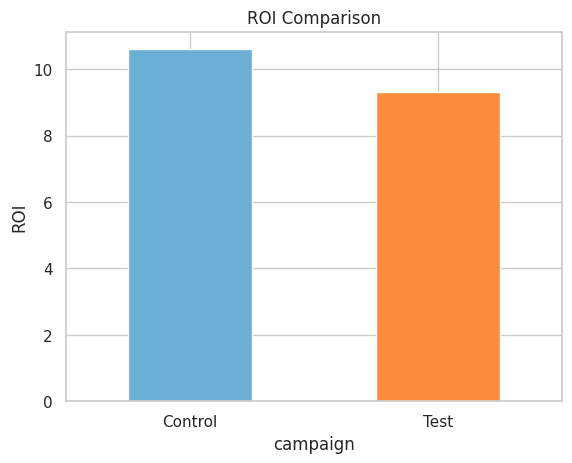

In [ ]:
df.groupby('campaign')['roi'].mean().plot(
    kind='bar',
    color=colors
)

plt.title("ROI Comparison")
plt.ylabel("ROI")
plt.xticks(rotation=0)
plt.show()

# CAC Analysis

In [ ]:
cac = df.groupby('campaign').apply(
    lambda x: x['spend'].sum() / x['purchase'].sum()
)

cac

/tmp/ipykernel_11389/1099789534.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cac = df.groupby('campaign').apply(


,0
campaign,
Control,4.407229
Test,4.917312


/tmp/ipykernel_11389/3849357780.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cac = df.groupby('campaign').apply(


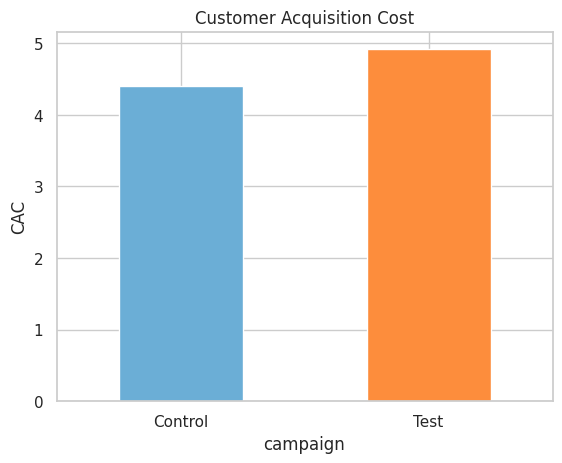

In [ ]:
cac = df.groupby('campaign').apply(
    lambda x: x['spend'].sum() / x['purchase'].sum()
)

cac.plot(kind='bar', color=colors)
plt.title("Customer Acquisition Cost")
plt.ylabel("CAC")
plt.xticks(rotation=0)
plt.show()

# Time Trend

In [ ]:
# Revenue per date & campaign
time_trend = df.groupby(['date', 'campaign'])['revenue'].sum().unstack()

time_trend.head()

campaign,Control,Test
date,,
2019-08-01,30900.0,12750.0
2019-08-02,25550.0,33850.0
2019-08-03,18600.0,28900.0
2019-08-04,17000.0,17000.0
2019-08-05,NaN,38400.0


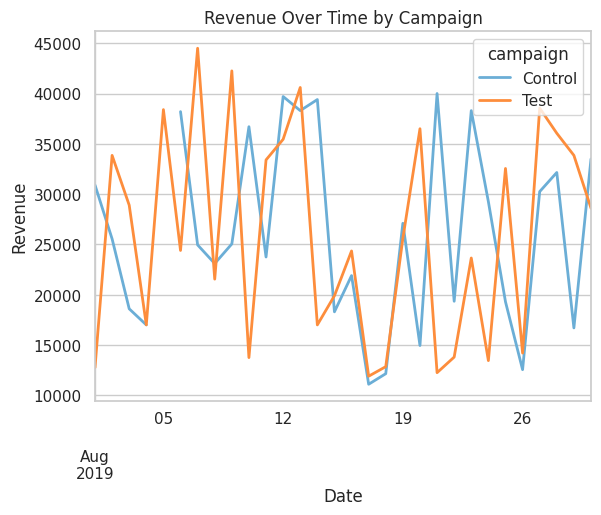

In [ ]:
df.groupby(['date','campaign'])['revenue'].sum().unstack().plot(
    color=colors,
    linewidth=2
)

plt.title("Revenue Over Time by Campaign")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

#Break-even Analysis

In [ ]:
profit_per_customer = df.groupby('campaign')['profit'].mean()
total_spend = df.groupby('campaign')['spend'].sum()

break_even = total_spend / profit_per_customer

break_even

,0
campaign,
Control,2.803287
Test,3.272195


# What-if Analysis

In [ ]:
df['spend_whatif'] = df['spend'] * 1.2
df['revenue_whatif'] = df['revenue'] * 1.1
df['profit_whatif'] = df['revenue_whatif'] - df['spend_whatif']

df.groupby('campaign')[['profit','profit_whatif']].sum()

,profit,profit_whatif
campaign,,
Control,691232.0,753673.4
Test,704958.0,767764.6


# Scenario Analysis

In [ ]:
scenarios = [0.95, 1.0, 1.1]

results = []

for s in scenarios:
    temp = df.copy()
    temp['rev_scenario'] = temp['purchase'] * AOV * s
    temp['profit_scenario'] = temp['rev_scenario'] - temp['spend']

    results.append(temp.groupby('campaign')['profit_scenario'].sum())

pd.DataFrame(results, index=['pessimistic','realistic','optimistic'])

campaign,Control,Test
pessimistic,653329.5,665865.5
realistic,691232.0,704958.0
optimistic,767037.0,783143.0


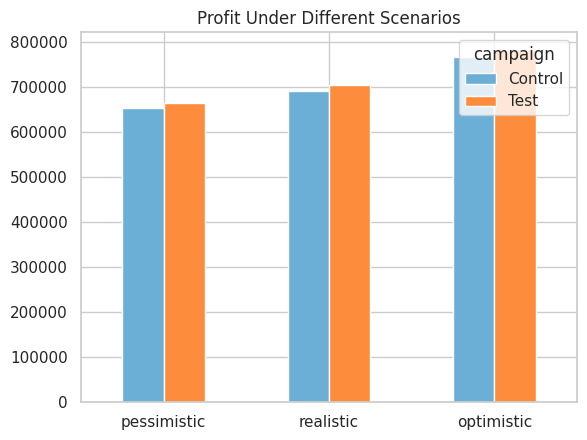

In [ ]:
scenario_profit = pd.DataFrame(results, index=['pessimistic','realistic','optimistic'])

scenario_profit.plot(
    kind='bar',
    color=colors
)

plt.title("Profit Under Different Scenarios")
plt.xticks(rotation=0)
plt.show()

# Segment Analysis

In [ ]:
# Time-based
df['day_type'] = df['date'].dt.weekday < 5

df.groupby(['day_type','campaign'])['purchase_rate'].mean()

day_type  campaign
False     Control     0.332698
          Test        0.607272
True      Control     0.504600
          Test        0.621831
Name: purchase_rate, dtype: float64

In [ ]:
# Reach-based
df['reach_segment'] = pd.qcut(df['reach'], q=2, labels=['low','high'])

df.groupby(['reach_segment','campaign'])['purchase_rate'].mean()

/tmp/ipykernel_11389/2902836802.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['reach_segment','campaign'])['purchase_rate'].mean()


reach_segment  campaign
low            Control     0.388204
               Test        0.596120
high           Control     0.483455
               Test        0.677978
Name: purchase_rate, dtype: float64

# Funnel Bottleneck Analysis

In [ ]:
drop = pd.DataFrame({
    'click_rate': funnel['clicks'] / funnel['impressions'],
    'view_rate': funnel['view_content'] / funnel['clicks'],
    'cart_rate': funnel['add_to_cart'] / funnel['view_content'],
    'purchase_rate': funnel['purchase'] / funnel['add_to_cart']
})

drop

,click_rate,view_rate,cart_rate,purchase_rate
campaign,,,,
Control,0.048565,0.365320,0.668795,0.402149
Test,0.080879,0.308007,0.474453,0.591280


# Executive Summary

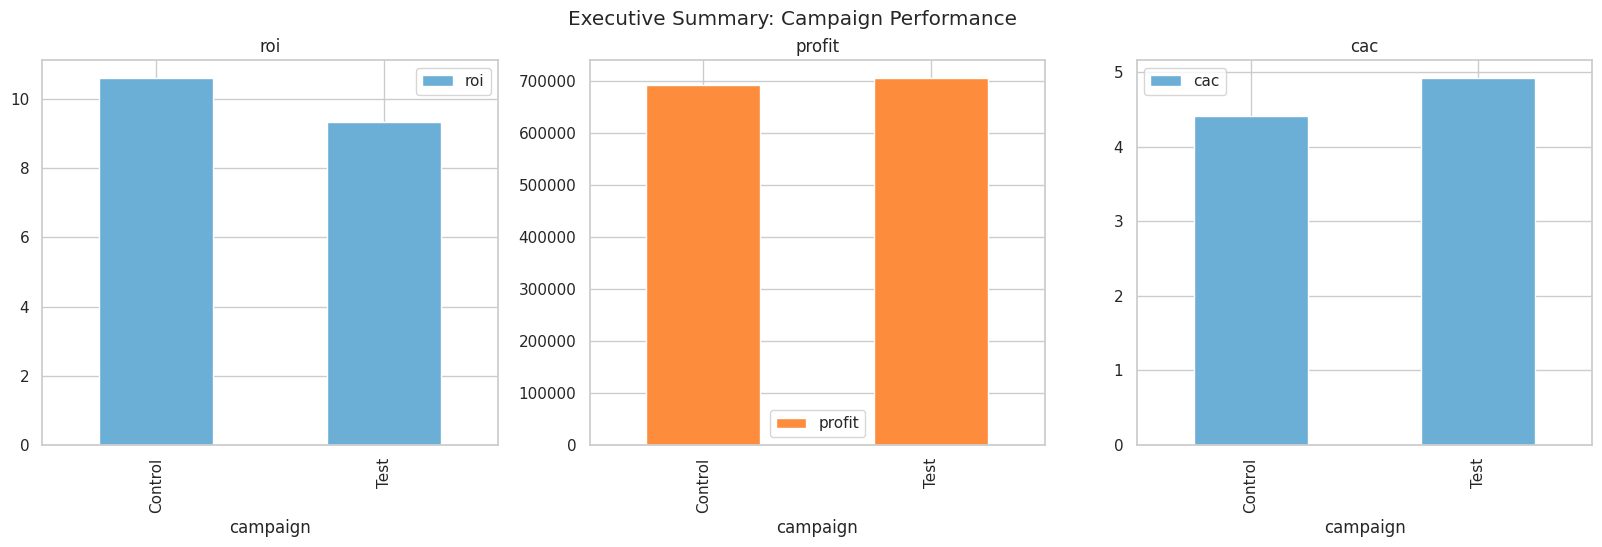

In [ ]:
summary = df.groupby('campaign').agg({
    'roi': 'mean',
    'profit': 'sum',
    'spend': 'sum',
    'purchase': 'sum'
})

summary['cac'] = summary['spend'] / summary['purchase']

summary[['roi','profit','cac']].plot(
    kind='bar',
    subplots=True,
    layout=(1,3),
    figsize=(20,5),
    sharex=True,
    color=colors
)

plt.suptitle("Executive Summary: Campaign Performance")
plt.show()

Made by Jihan Kamilah